In [1]:
# Risking a Southern North Sea gas exploration well
# A hypothetical single-well prospect. all inputs are illustrative 

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N = 100_000
Z90 = 1.2816

In [3]:
# Volumetrics (BCF). P90 is the low case, P10 the high case
GIIP_P90, GIIP_P10 = 10.0, 40.0
RF_MIN, RF_MODE, RF_MAX = 0.65, 0.75, 0.85

# Costs (GBP m)
WELL_COST = 25.0
COST_MIN, COST_MODE, COST_MAX = 0.90 * WELL_COST, WELL_COST, 1.15 * WELL_COST
SPREAD_RATE = 0.20
NPT_MIN, NPT_MODE, NPT_MAX = 0, 10, 50

# Commercial
PRICE_MEDIAN, PRICE_SIGMA = 70.0, 0.25
OPEX_PER_BCF = 1.0
THERMS_PER_BCF = 10.37e6

# Production and discounting
DISCOUNT, DECLINE, YEARS = 0.10, 0.20, 10

# Chance of success
PLAY = {"Source": 1.0, "Charge": 0.80, "Reservoir": 0.90, "Trap/Seal": 0.55}
COS = float(np.prod(list(PLAY.values())))
print(f"Overall chance of success: {COS:.1%}")

Overall chance of success: 39.6%


In [4]:
mu = (np.log(GIIP_P10) + np.log(GIIP_P90)) / 2
sigma = (np.log(GIIP_P10) - np.log(GIIP_P90)) / (2 * Z90)
print(np.exp(mu), sigma)

20.000000000000007 0.5408451783395327


In [5]:
# 2. Economic Model 
# Reserves = GIIP x recovery factor. 
# Each BCF earns price minus opex. Production declines 20% a year for 10 years and is discounted mid-year. 
# The well cost is spent up front, plus the cost of any extra days lost to NPT.


In [6]:
years = np.arange(YEARS)
share = (1 - DECLINE) ** years
share = share / share.sum()
PV_FACTOR = float((share / (1 + DISCOUNT) ** (years + 0.5)).sum())
print(PV_FACTOR)

0.750886410015419


In [7]:
def well_model(giip, rf, price, base_cost, npt_days):
    reserves = giip * rf
    margin = THERMS_PER_BCF / 1e6 * price / 100 - OPEX_PER_BCF
    cost = base_cost + npt_days * SPREAD_RATE
    undiscounted = reserves * margin - cost
    discounted = PV_FACTOR * reserves * margin - cost
    return undiscounted, discounted, cost

    

In [8]:
## 3. Monte Carlo

In [9]:
inputs = pd.DataFrame({
    "giip": rng.lognormal(mu, sigma, N),
    "rf": rng.triangular(RF_MIN, RF_MODE, RF_MAX, N),
    "price": rng.lognormal(np.log(PRICE_MEDIAN), PRICE_SIGMA, N),
    "base_cost": rng.triangular(COST_MIN, COST_MODE, COST_MAX, N),
    "npt_days": rng.triangular(NPT_MIN, NPT_MODE, NPT_MAX, N),
})

In [10]:
undisc, npv, total_cost = well_model(
    inputs["giip"], inputs["rf"], inputs["price"],
    inputs["base_cost"], inputs["npt_days"])

In [11]:
inputs.head()

,giip,rf,price,base_cost,npt_days
0,23.583258,0.746476,66.682645,24.062621,17.672546
1,11.395994,0.831070,74.875479,23.069266,11.141744
2,30.012387,0.837330,118.928147,24.779951,32.816375
3,33.262551,0.819749,96.210787,27.107794,14.816705
4,6.962400,0.820092,50.377296,23.456773,42.492090


In [21]:
def p_cases(x):
    return pd.Series({"P90": np.percentile(x, 10), "P50": np.percentile(x, 50),
                      "P10": np.percentile(x, 90), "Mean": np.mean(x)})

In [20]:
summary = pd.DataFrame({
    "GIIP (BCF)": p_cases(inputs["giip"]),
    "Reserves (BCF)": p_cases(inputs["giip"] * inputs["rf"]),
    "Total well cost (GBP m)": p_cases(total_cost),
    "Undiscounted net cash flow (GBP m)": p_cases(undisc),
    "Discounted NPV (GBP m)": p_cases(npv),
}).T.round(1)
summary

,P90,P50,P10,Mean
GIIP (BCF),10.0,19.9,40.0,23.1
Reserves (BCF),7.4,14.9,30.1,17.3
Total well cost (GBP m),26.3,29.2,32.9,29.4
Undiscounted net cash flow (GBP m),12.7,63.6,176.1,83.1
Discounted NPV (GBP m),2.1,40.5,124.9,55.1


In [14]:
## Histogram

In [22]:
print(f"Probability NPV < 0, given success: {(npv < 0).mean():.1%}")

Probability NPV < 0, given success: 8.2%


In [23]:
low, high = np.percentile(npv, [0.5, 99.5])
ax.hist(npv, bins=120, range=(low, high), color="#7a9cc6")

(array([ 530.,  828., 1149., 1506., 1838., 2117., 2315., 2558., 2755.,
        2958., 2987., 2954., 3037., 3059., 2961., 2997., 2941., 2827.,
        2727., 2678., 2528., 2466., 2375., 2258., 2214., 2093., 1910.,
        1817., 1788., 1625., 1604., 1520., 1423., 1324., 1260., 1218.,
        1127., 1104., 1046.,  937.,  890.,  839.,  804.,  775.,  744.,
         700.,  688.,  658.,  606.,  545.,  581.,  517.,  500.,  443.,
         456.,  378.,  393.,  362.,  337.,  341.,  303.,  301.,  288.,
         268.,  224.,  245.,  247.,  223.,  214.,  207.,  188.,  202.,
         178.,  159.,  138.,  157.,  140.,  136.,  118.,   96.,  112.,
         122.,  110.,  110.,   73.,   80.,   76.,   95.,   75.,   72.,
          62.,   57.,   76.,   48.,   49.,   52.,   49.,   63.,   49.,
          45.,   38.,   39.,   42.,   39.,   35.,   23.,   37.,   33.,
          32.,   27.,   31.,   22.,   27.,   18.,   22.,   34.,   22.,
          15.,   20.,   21.]),
 array([-1.61046979e+01, -1.33701758e+01, -1.0

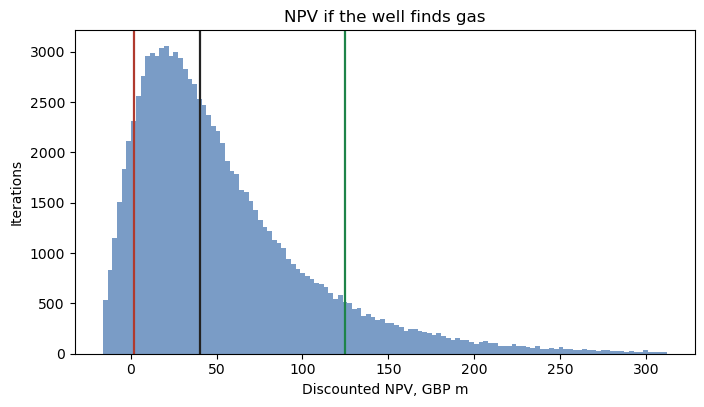

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.2))

low, high = np.percentile(npv, [0.5, 99.5])
ax.hist(npv, bins=120, range=(low, high), color="#7a9cc6")

p = p_cases(npv)
for name, colour in (("P90", "#b03a2e"), ("P50", "#222222"), ("P10", "#1e8449")):
    ax.axvline(p[name], color=colour, lw=1.6)

ax.set_xlabel("Discounted NPV, GBP m")
ax.set_ylabel("Iterations")
ax.set_title("NPV if the well finds gas")
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/npv_distribution.png", dpi=200)
plt.show()

In [ ]:
## Sensitivity

In [25]:
LABELS = {"giip": "GIIP", "rf": "Recovery factor", "price": "Gas price",
          "base_cost": "Base well cost", "npt_days": "Extra NPT days"}

base = inputs.median()
base_npv = well_model(**base.to_dict())[1]
print("NPV with every input at its median:", round(base_npv, 1))

NPV with every input at its median: 41.2


In [26]:
rows = []
for col in inputs.columns:
    low, high = inputs[col].quantile([0.10, 0.90])
    n_low = well_model(**{**base.to_dict(), col: low})[1]
    n_high = well_model(**{**base.to_dict(), col: high})[1]
    rank_corr = inputs[col].rank().corr(pd.Series(npv).rank())
    rows.append({"input": LABELS[col], "npv_low": n_low, "npv_high": n_high,
                 "swing": abs(n_high - n_low), "rank_corr": rank_corr})

tornado = pd.DataFrame(rows).sort_values("swing", ascending=False).reset_index(drop=True)
tornado.round(2)

,input,npv_low,npv_high,swing,rank_corr
0,GIIP,6.12,112.12,106.00,0.87
1,Gas price,18.98,71.75,52.77,0.45
2,Recovery factor,36.05,46.39,10.34,0.08
3,Extra NPT days,43.44,37.68,5.77,-0.05
4,Base well cost,42.76,39.30,3.47,-0.03


In [27]:
giip_swing = tornado.loc[tornado["input"] == "GIIP", "swing"].iloc[0]
print(f"Extra days needed to lose as much as the GIIP swing: {giip_swing / SPREAD_RATE:.0f}")
print(f"Upper limit of the NPT distribution used here: {NPT_MAX} days")

Extra days needed to lose as much as the GIIP swing: 530
Upper limit of the NPT distribution used here: 50 days


In [ ]:
## Tornando Chart

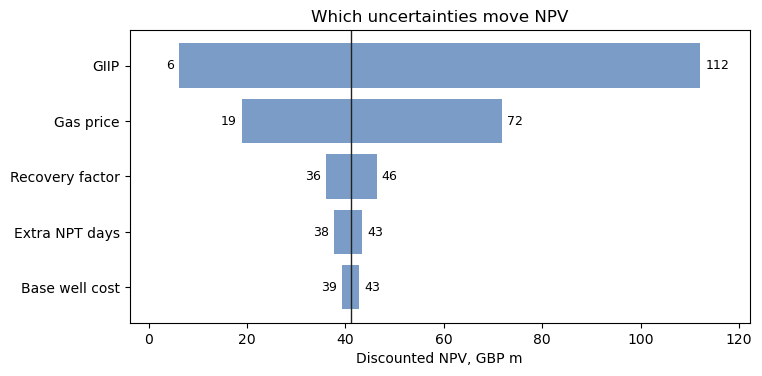

In [28]:
fig, ax = plt.subplots(figsize=(8, 3.8))

plot_df = tornado.iloc[::-1].reset_index(drop=True)
for i, r in plot_df.iterrows():
    a, b = sorted([r["npv_low"], r["npv_high"]])
    ax.barh(i, b - a, left=a, color="#7a9cc6")
    ax.text(a - 1, i, f"{a:.0f}", ha="right", va="center", fontsize=9)
    ax.text(b + 1, i, f"{b:.0f}", ha="left", va="center", fontsize=9)

ax.axvline(base_npv, color="#222222", lw=1)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["input"])
vals = plot_df[["npv_low", "npv_high"]].to_numpy().ravel()
ax.set_xlim(vals.min() - 10, vals.max() + 10)
ax.set_xlabel("Discounted NPV, GBP m")
ax.set_title("Which uncertainties move NPV")
os.makedirs("figures", exist_ok=True)
fig.savefig("figures/tornado.png", dpi=200)
plt.show()

In [ ]:
## 5. Geological risk and expected value

In [ ]:
for small in (5.0, 2.0, 1.0):
    z = (np.log(small) - mu) / sigma
    count = (inputs["giip"] <= small).sum()
    print(f"{small} BCF: z-score {z:.1f}, draws at or below it: {count} of {N}")

In [ ]:
e_success = npv.mean()
fail_cost = total_cost.mean()
emv = COS * e_success - (1 - COS) * fail_cost
breakeven_cos = fail_cost / (e_success + fail_cost)

In [ ]:
tree = pd.DataFrame(
    {"Probability": [COS, 1 - COS], "Value (GBP m)": [e_success, -fail_cost]},
    index=["Success", "Dry hole"])
tree["Weighted (GBP m)"] = tree["Probability"] * tree["Value (GBP m)"]
print(tree.round(3))
print(f"Expected monetary value (EMV): GBP {emv:.1f} m")
print(f"Break-even chance of success: {breakeven_cos:.1%} (case: {COS:.1%})")

In [ ]:
cos_grid = np.linspace(0.05, 0.80, 200)
emv_grid = cos_grid * e_success - (1 - cos_grid) * fail_cost

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cos_grid * 100, emv_grid, color="#2e5c8a", lw=2)
ax.axhline(0, color="#888888", lw=1)
ax.axvline(COS * 100, color="#222222", ls="--", lw=1)
ax.axvline(breakeven_cos * 100, color="#b03a2e", ls="--", lw=1)
ax.set_xlabel("Geological chance of success (%)")
ax.set_ylabel("EMV, GBP m")
ax.set_title("Expected value of drilling against chance of success")
plt.show()

In [ ]:
## 6. Conclusions

**If the well finds gas.** The median NPV is about £40m. The low case (P90) is about £2m and the high case (P10) is about £125m, so the range is wide. About 8% of outcomes still lose money, because a small volume at a low gas price cannot pay back a well costing £25m to £30m.

**Volume and price drive the result.** Moving GIIP from its 10th to its 90th percentile changes NPV by about £106m. Gas price changes it by about £53m. Recovery factor, extra NPT days and base well cost each change it by only £3m to £10m. NPT would need to reach around 530 extra days to match the GIIP swing, and the model caps it at 50. Cost overruns hurt but can be absorbed. A volume shortfall cannot.

**A dry hole is a separate outcome.** A GIIP of 2 BCF or less came up once in 100,000 draws, so a dry hole cannot be explained by the volume range. It has to be its own branch in the decision, which is what chance of success covers.

**The decision is close.** With a 39.6% chance of success, the expected value of drilling is about £4m. Break-even is 34.8%, less than five points lower. Trap/seal, at 0.55, is the weakest of the four geological elements, so firming that up is worth more than trimming the well cost.

**A caveat.** Every input is an illustrative assumption. The ranking of the drivers depends on the ranges chosen, especially the spread on gas price, so the method matters more than the specific figures.

In [ ]:
## 7. Limitations


- Inputs are sampled independently. In practice GIIP and recovery factor are usually linked, and ignoring that changes the spread of outcomes.
- It is a single well on a gross basis, with no tax, no development costs beyond the well, and a simple 20% annual decline.
- Gas price is one lognormal draw, with no forward curve and no link to any other input.
- A dry hole is assumed to cost the full well cost including extra days. A well stopped early would cost less.
- Chance of success is treated as a known number. In reality it is a judgement and is itself uncertain.
- All inputs are round numbers chosen for illustration.